In [19]:
from CiCMoments import *
from CountsinCylinders import *
import matplotlib

#set up auto-reload for development purposes

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
def plotMomentRatio(ratio,title,saveas='forpaper/momentratio.png',asterisks = []):
    matplotlib.fontsize = 25
    data = np.ones((4,4))
    for i in range(4):
        for j in range(4):
            if i + j > 3:
                data[i][j] = None
    data
    for row in ratio:
        data[int(row['ELG Order, LRG Order'][0])][int(row['ELG Order, LRG Order'][1])] = row['Moment']
    fig,ax = plt.subplots()
    pc = ax.pcolormesh(np.arange(4),np.arange(4),data,cmap='RdBu_r',vmin=0.7,vmax=1.3)
    ax.set_xlabel(r"LRG Order $n$",fontsize=20,labelpad=20)
    ax.set_ylabel(r"ELG Order $m$",fontsize=20,labelpad=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xticks([0,1,2,3],labelsize=50)
    ax.set_yticks([0,1,2,3])
    ax.tick_params(axis='both', which='both', length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(title,fontsize=24,pad=20)
    cbar = plt.colorbar(pc)

    cbar.outline.set_visible(False)
    for row in ratio:
        if np.abs(row['Moment'] - 1) > 2*row['Standard Error']:
            i,j = row['ELG Order, LRG Order']
            ax.text(j+0.3-0.5,i+0.3-0.5,"*",color='black',size=25,path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)
    for asterisk in asterisks:
        i = asterisk[0]
        j = asterisk[1]
        ax.text(j+0.3-0.5,i+0.3-0.5,"*",color='black',size=25,path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)
    ax.text(4.7, 0, "Ratio of Moments (Mock / SV3)",rotation=90, rotation_mode='anchor',transform_rotates_text=True,fontsize=18)
    plt.savefig(saveas,bbox_inches='tight')

In [21]:
filetag = "inc_corrected"

In [22]:
ab_elg_momsimple = Table.read("ab_elg_momsimple"+filetag+".ecsv")
ab_lrg_momsimple = Table.read("ab_lrg_momsimple"+filetag+".ecsv")


sv3_elg_momsimple = Table.read("sv3_elg_momsimple"+filetag+".ecsv") #,savesubsamples=True)
sv3_lrg_momsimple = Table.read("sv3_lrg_momsimple"+filetag+".ecsv") #,savesubsamples=True)

In [23]:
compelg_simple = momentRatio(ab_elg_momsimple,sv3_elg_momsimple)
complrg_simple = momentRatio(ab_lrg_momsimple,sv3_lrg_momsimple)

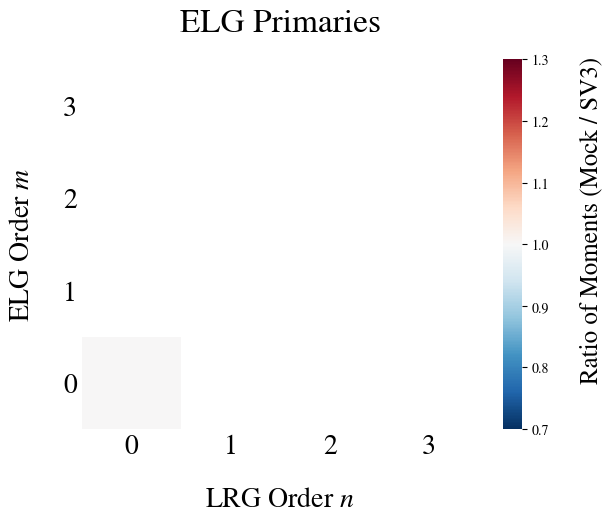

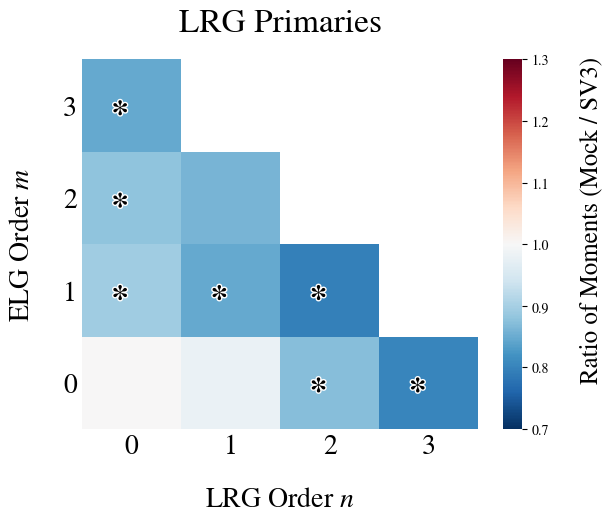

In [24]:
plotMomentRatio(compelg_simple,"ELG Primaries",saveas="forpaper/elgmomentratio.png")

plotMomentRatio(complrg_simple,"LRG Primaries",saveas="forpaper/lrgmomentratio.png")

In [25]:
ab_elg_momfactorial = Table.read('ab_elg_momfactorial'+filetag+'.ecsv')
ab_lrg_momfactorial = Table.read('ab_lrg_momfactorial'+filetag+'.ecsv')


sv3_elg_momfactorial = Table.read('sv3_elg_momfactorial'+filetag+'.ecsv')
sv3_lrg_momfactorial = Table.read('sv3_lrg_momfactorial'+filetag+'.ecsv')

In [26]:
compelg_factorial = momentRatio(ab_elg_momfactorial,sv3_elg_momfactorial)
complrg_factorial = momentRatio(ab_lrg_momfactorial,sv3_lrg_momfactorial)

In [27]:
ab_elg_ntilde = Table.read('ab_elg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')
ab_lrg_ntilde = Table.read('ab_lrg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')
sv3_elg_ntilde = Table.read('sv3_elg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')
sv3_lrg_ntilde = Table.read('sv3_lrg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')

compelg_ntilde = momentRatio(ab_elg_ntilde,sv3_elg_ntilde)
complrg_ntilde = momentRatio(ab_lrg_ntilde,sv3_lrg_ntilde)

In [28]:
abran_elg_momsimple = Table.read(filename='abran_elg_momsimple'+filetag+'.ecsv',format = 'ascii.ecsv')
abran_lrg_momsimple = Table.read('abran_lrg_momsimple'+filetag+'.ecsv',format = 'ascii.ecsv')

#extraargs = [Vcyl,sv3_elg_nZ,sv3_lrg_nZ]
sv3ran_elg_momsimple = Table.read('sv3ran_elg_momsimple'+filetag+'.ecsv',format = 'ascii.ecsv')
sv3ran_lrg_momsimple = Table.read('sv3ran_lrg_momsimple'+filetag+'.ecsv',format = 'ascii.ecsv')

In [29]:
abran_elg_ntilde = Table.read('abran_elg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')
abran_lrg_ntilde = Table.read('abran_lrg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')

sv3ran_elg_ntilde = Table.read('sv3ran_elg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')
sv3ran_lrg_ntilde = Table.read('sv3ran_lrg_ntilde'+filetag+'.ecsv',format = 'ascii.ecsv')

In [30]:
ab_elg_nz = Table.read("ab_elg_nz"+filetag+".ecsv")
ab_lrg_nz = Table.read("ab_lrg_nz"+filetag+".ecsv")

sv3_elg_nz = Table.read("sv3_elg_nz"+filetag+".ecsv")
sv3_lrg_nz = Table.read("sv3_lrg_nz"+filetag+".ecsv")

In [31]:
ab_elg_vcyl = Table.read("ab_elg_vcyl"+filetag+".ecsv")
ab_lrg_vcyl = Table.read("ab_lrg_vcyl"+filetag+".ecsv")

sv3_elg_vcyl = Table.read("sv3_elg_vcyl"+filetag+".ecsv")
sv3_lrg_vcyl = Table.read("sv3_lrg_vcyl"+filetag+".ecsv")

In [32]:
sv3_elg_npcf = avgnpcf(sv3_elg_ntilde,sv3ran_elg_ntilde,sv3_elg_nz,sv3_elg_vcyl)
sv3_lrg_npcf = avgnpcf(sv3_lrg_ntilde,sv3ran_lrg_ntilde,sv3_lrg_nz,sv3_lrg_vcyl)

ab_elg_npcf = avgnpcf(ab_elg_ntilde,abran_elg_ntilde,ab_elg_nz,ab_elg_vcyl)
ab_lrg_npcf = avgnpcf(ab_lrg_ntilde,abran_lrg_ntilde,ab_lrg_nz,ab_elg_vcyl)

In [33]:
compelg_npcf = momentRatio(ab_elg_npcf,sv3_elg_npcf)
complrg_npcf = momentRatio(ab_lrg_npcf,sv3_lrg_npcf)

In [34]:
'''asterisks = [[1,0],[0,2]]
plotMomentRatio(compelg_npcf,"ELG Primaries",saveas="forpaper/elgmomentratio_npcf.png",asterisks = asterisks)

asterisks = [[0,2],[1,0],[1,1],[1,2],[0,3]]
plotMomentRatio(complrg_npcf,"LRG Primaries",saveas="forpaper/lrgmomentratio_npcf.png",asterisks = asterisks)'''

'asterisks = [[1,0],[0,2]]\nplotMomentRatio(compelg_npcf,"ELG Primaries",saveas="forpaper/elgmomentratio_npcf.png",asterisks = asterisks)\n\nasterisks = [[0,2],[1,0],[1,1],[1,2],[0,3]]\nplotMomentRatio(complrg_npcf,"LRG Primaries",saveas="forpaper/lrgmomentratio_npcf.png",asterisks = asterisks)'

In [38]:

string1 = printMomentTableLaTeX(sv3_elg_momsimple,"Moments of ELG-Centered Counts in Cylinders Distribution in SV3",lrg=False)
print(string1)
string1 = printMomentTableLaTeX(sv3_lrg_momsimple,"Moments of LRG-Centered Counts in Cylinders Distribution in SV3",lrg=True)
print(string1)



ValueError: cannot convert float NaN to integer

In [42]:
sv3_lrg_npcf

"ELG Order, LRG Order",Moment,Standard Error
int64[2],float64,float64
0 .. 1,15.764964830665217,0.6335971131184173
0 .. 2,760.6111696162644,77.19568274069003
0 .. 3,48868.77912251801,7975.259310156051
1 .. 0,3.1037798585287124,0.16807740596867032
1 .. 1,70.53961602193142,7.438089874372406
1 .. 2,3610.2840131524545,678.8089821171487
2 .. 0,18.9461277073568,3.752200082554882
2 .. 1,458.14206142285826,122.02140658463753
3 .. 0,266.2296765383279,163.64115113155384


In [ ]:
string1 = printMomentTableLaTeX(compelg_simple,"Moments of ELG-Centered Counts in Cylinders Distribution: Ratio of Abacus to SV3",lrg=False)
print(string1)
string1 = printMomentTableLaTeX(complrg_simple,"Moments of LRG-Centered Counts in Cylinders Distribution: Ratio of Abacus to SV3",lrg=True)
print(string1)


string1 = printMomentTableLaTeX(sv3_elg_npcf,r"ELG-Centered $\bar{\xi}_{\text{cyl}}$ in SV3",lrg=False,scientific=True)
print(string1)
string1 = printMomentTableLaTeX(sv3_lrg_npcf,r"LRG-Centered $\bar{\xi}_{\text{cyl}}$ in SV3",lrg=True,scientific=True)
print(string1)

string1 = printMomentTableLaTeX(compelg_npcf,r'''$\bar{\xi}$: Ratio of Mock Catalogs to SV3, ELG-Centered''',lrg=False)
print(string1)
string1 = printMomentTableLaTeX(complrg_npcf,r'''$\bar{\xi}$: Ratio of Mock Catalogs to SV3, LRG-Centered''',lrg=True)
print(string1)

In [18]:
'''string1 = printMomentTableLaTeX(compelg_ntilde,r"$\tilde{N}$ in ELG-Centered Counts in Cylinders Distribution: Ratio of Abacus to SV3",lrg=False)
print(string1)
string1 = printMomentTableLaTeX(complrg_ntilde,r"$\tilde{N}$ LRG-Centered Counts in Cylinders Distribution: Ratio of Abacus to SV3",lrg=True)
print(string1)''''

SyntaxError: unterminated string literal (detected at line 4) (4259111538.py, line 4)

In [17]:
string1 = printMomentTableLaTeX(sv3_elg_npcf,r"ELG-Centered $\bar{\xi}_{\text{cyl}}$ in SV3",lrg=False,scientific=True)
print(string1)
string1 = printMomentTableLaTeX(ab_elg_npcf,r"ELG-Centered $\bar{\xi}_{\text{cyl}}$ in Abacus",lrg=False,scientific=True)
print(string1)
string1 = printMomentTableLaTeX(sv3_lrg_npcf,r"LRG-Centered $\bar{\xi}_{\text{cyl}}$ in SV3",lrg=True,scientific=True)
print(string1)
string1 = printMomentTableLaTeX(ab_lrg_npcf,r"LRG-Centered $\bar{\xi}_{\text{cyl}}$ in Abacus",lrg=True,scientific=True)
print(string1)


    \begin{table}
    \caption{ELG-Centered $\bar{\xi}_{\text{cyl}}$ in SV3}
    \begin{tabular}{ c  c  c  c c c}
    \multicolumn{2}{c}{}&\multicolumn{4}{c}{LRG Order}\\
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\ \cline{3-6}
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}{ELG Order}}& \multicolumn{1}{c|}{0} && 2.85 
 ( 0.156 ) & 60.6 
 ( 7.9 )&2.36e+03 
 ( 592 )\\
     & \multicolumn{1}{c|}{1} &2.62 
 ( 0.0784 )&13.7 
 ( 2.16 )&360 
 ( 98.2 )&\multicolumn{1}{c}{}\\
    
     &\multicolumn{1}{c|}{2} & 16.2 
 ( 4.71 )&123 
 ( 48.9 )& \multicolumn{2}{c}{}\\
     &\multicolumn{1}{c|}{3} &305 
 ( 300 )& \multicolumn{2}{c}{}\\
    
    \end{tabular}
    
    \end{table}

    \begin{table}
    \caption{ELG-Centered $\bar{\xi}_{\text{cyl}}$ in Abacus}
    \begin{tabular}{ c  c  c  c c c}
    \multicolumn{2}{c}{}&\multicolumn{4}{c}{LRG Order}\\
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\ \cline{3-6}
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}{ELG Order}}& \multicolumn{1}{c|}{

In [18]:
string1 = printMomentTableLaTeX(compelg_npcf,r'''$\bar{\xi}$: Ratio of Mock Catalogs to SV3, ELG-Centered''',lrg=False)
print(string1)
string1 = printMomentTableLaTeX(complrg_npcf,r'''$\bar{\xi}$: Ratio of Mock Catalogs to SV3, LRG-Centered''',lrg=True)
print(string1)


    \begin{table}
    \caption{$\bar{\xi}$: Ratio of Mock Catalogs to SV3, ELG-Centered}
    \begin{tabular}{ c  c  c  c c c}
    \multicolumn{2}{c}{}&\multicolumn{4}{c}{LRG Order}\\
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\ \cline{3-6}
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}{ELG Order}}& \multicolumn{1}{c|}{0} && 0.967 
 ( 0.053 ) & 0.859 
 ( 0.113 )&0.718 
 ( 0.181 )\\
     & \multicolumn{1}{c|}{1} &1.12 
 ( 0.0336 )&1.15 
 ( 0.182 )&1.19 
 ( 0.327 )&\multicolumn{1}{c}{}\\
    
     &\multicolumn{1}{c|}{2} & 0.81 
 ( 0.236 )&1.13 
 ( 0.454 )& \multicolumn{2}{c}{}\\
     &\multicolumn{1}{c|}{3} &0.375 
 ( 0.372 )& \multicolumn{2}{c}{}\\
    
    \end{tabular}
    
    \end{table}

    \begin{table}
    \caption{$\bar{\xi}$: Ratio of Mock Catalogs to SV3, LRG-Centered}
    \begin{tabular}{ c  c  c  c c c}
    \multicolumn{2}{c}{}&\multicolumn{4}{c}{ELG Order}\\
     \multicolumn{1}{c}{}& &  0&1&  2 &3\\ \cline{3-6}
    
    \multirow[|l|]{4}{*}{\rotatebox[origin=c]{90}